# 02 — KMeans Clustering
Features: `energy`, `acousticness`, `valence`, `tempo`, `danceability`

Goal: discover natural clusters, then overlay playlist labels to see alignment.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from dotenv import load_dotenv
import os

load_dotenv()
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT', 3306)}/{os.getenv('DB_NAME', 'spotify_analytics')}"
)
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110

## 1. Load Data

In [20]:
QUERY = """
SELECT
    s.spotify_id        AS track_id,
    s.name              AS track_name,
    pl.name             AS playlist_name,
    af.energy, af.acousticness, af.valence, af.tempo, af.danceability,
    af.speechiness
FROM fac_songs fs
JOIN dim_songs      s   ON fs.dim_song_id           = s.id
JOIN dim_playlist   pl  ON fs.dim_playlist_id       = pl.id
JOIN dim_audio_features af ON fs.dim_audio_features_id = af.id
JOIN bridge_song_artists bsa ON fs.dim_song_id      = bsa.dim_song_id
WHERE bsa.is_primary = TRUE
  AND pl.is_personal  = TRUE
  AND fs.dim_audio_features_id IS NOT NULL
"""

df = pd.read_sql(QUERY, engine)
df = df.drop_duplicates(subset='track_id', keep='first').reset_index(drop=True)
print(f'Tracks: {len(df):,}')

# Log-transform speechiness to fix zero-spike skew
df["speechiness_log"] = np.log1p(df["speechiness"])

FEATURES = ['energy', 'acousticness', 'valence', 'tempo', 'danceability', 'speechiness_log']
X = df[FEATURES].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaled shape:', X_scaled.shape)

Tracks: 2,544
Scaled shape: (2544, 6)


## 2. Elbow + Silhouette — Pick k

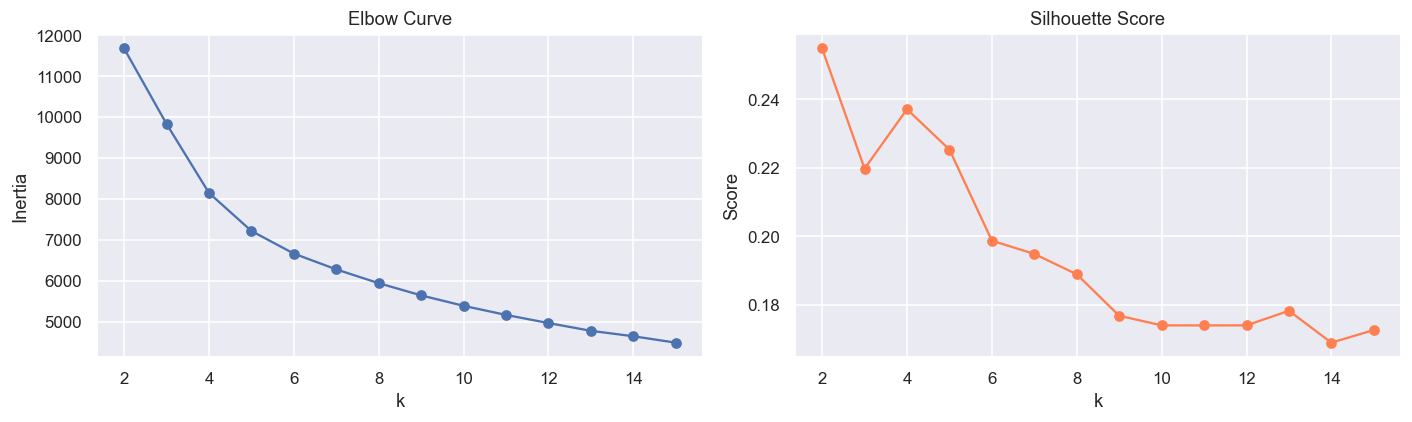

Best k by silhouette: 4


In [21]:
K_RANGE = range(2, 16)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_RANGE, inertias, marker='o')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_RANGE, silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

# best_k = K_RANGE[silhouettes.index(max(silhouettes))]
best_k = 4  # silhouette peaks at k=2 (high-speech vs tonal split) but is too coarse;
             # secondary peak at k=4 gives interpretable sub-clusters while preserving
             # the primary speech/tonal axis; elbow shows diminishing returns after k=5
print(f'Best k by silhouette: {best_k}')

## 3. Fit Final Model

In [22]:
# Adjust K here if elbow suggests a different value than silhouette
K = best_k

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print(f'Cluster sizes:')
print(df['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0     736
1    1057
2     117
3     634
Name: count, dtype: int64


## 4. PCA Visualization

Variance explained: PC1=33.9%, PC2=22.7%, Total=56.6%


C:\Users\facur\AppData\Local\Temp\ipykernel_19788\1737926598.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', len(playlists))


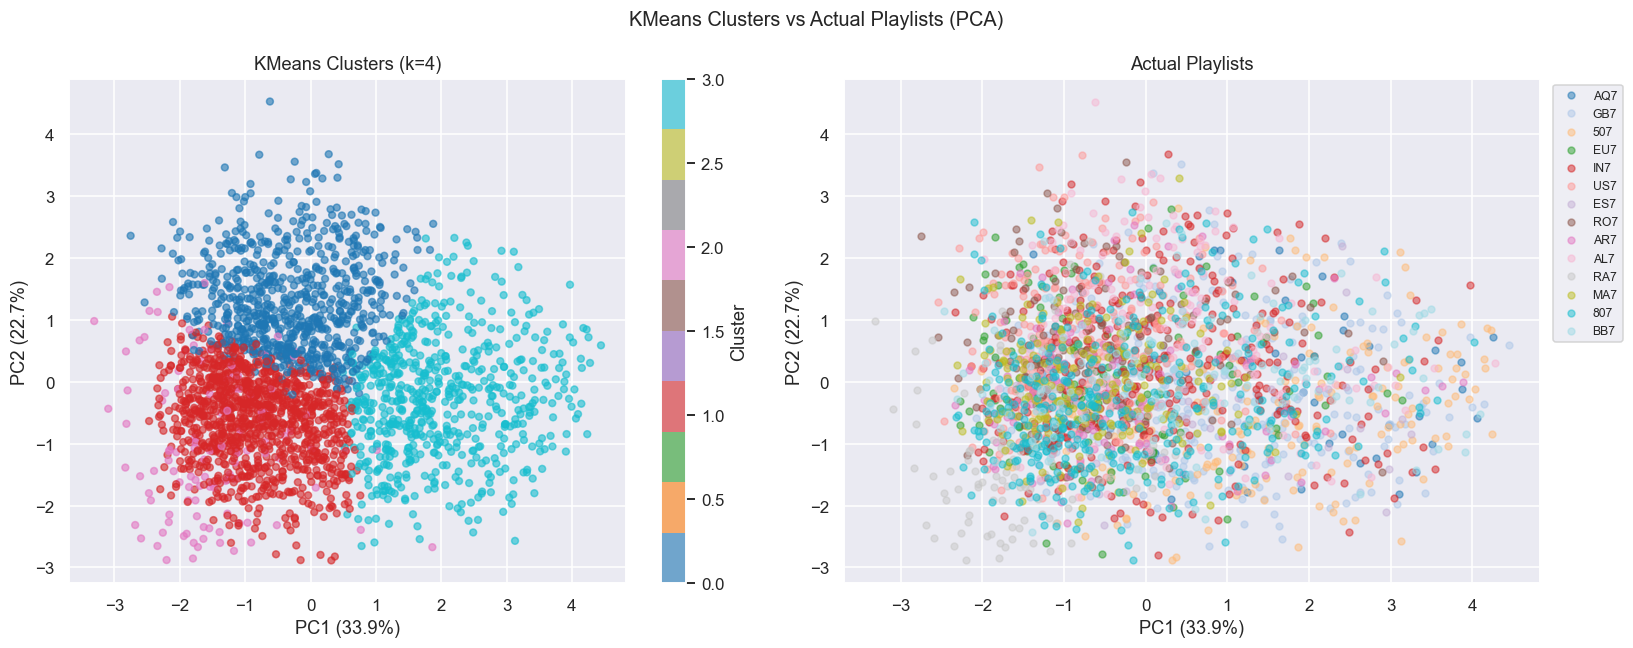

In [23]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df['pc1'] = coords[:, 0]
df['pc2'] = coords[:, 1]

print(f'Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.1%}, '
      f'Total={sum(pca.explained_variance_ratio_):.1%}')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: colored by cluster
scatter = axes[0].scatter(df['pc1'], df['pc2'], c=df['cluster'],
                          cmap='tab10', alpha=0.6, s=20)
axes[0].set_title(f'KMeans Clusters (k={K})')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Right: colored by playlist
playlists = df['playlist_name'].unique()
cmap = plt.cm.get_cmap('tab20', len(playlists))
for i, pl in enumerate(playlists):
    mask = df['playlist_name'] == pl
    axes[1].scatter(df.loc[mask, 'pc1'], df.loc[mask, 'pc2'],
                    color=cmap(i), alpha=0.5, s=20, label=pl)
axes[1].set_title('Actual Playlists')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('KMeans Clusters vs Actual Playlists (PCA)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Cluster Profiles

         energy  acousticness  valence    tempo  danceability  speechiness_log
cluster                                                                       
0         0.750         0.095    0.449  137.227         0.445            0.049
1         0.715         0.166    0.748  116.461         0.652            0.041
2         0.712         0.218    0.650  119.152         0.684            0.229
3         0.365         0.596    0.383  108.442         0.507            0.037


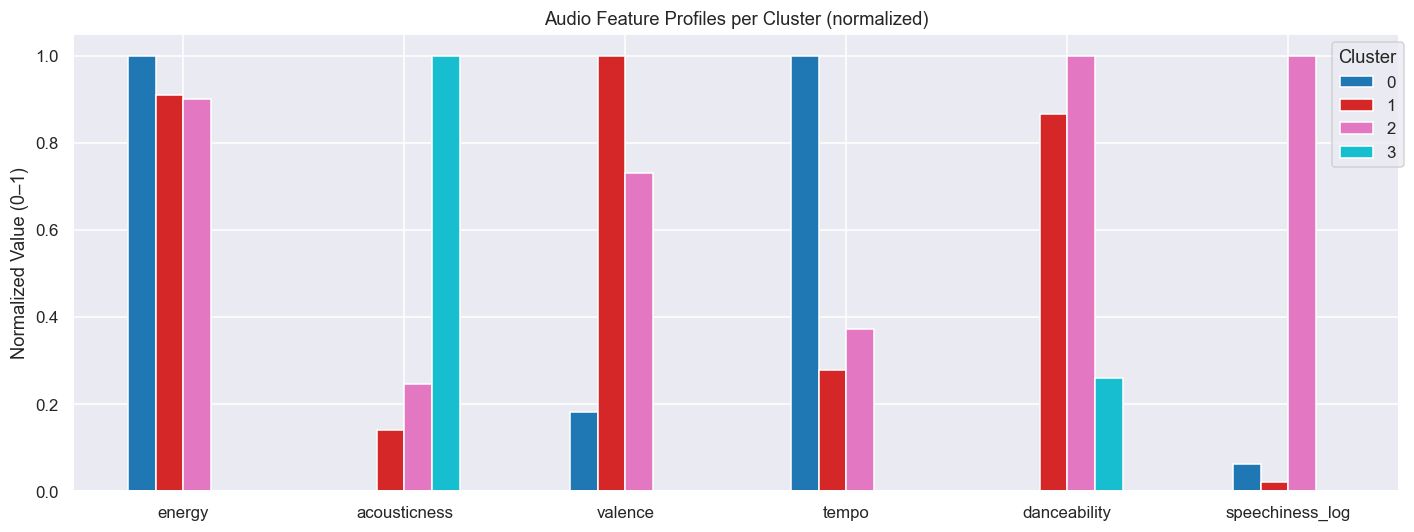

In [24]:
# Mean feature values per cluster
profiles = df.groupby('cluster')[FEATURES].mean().round(3)
print(profiles)

# Normalized chart (0-1 scale so tempo doesn't dominate)
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min())
profiles_norm.T.plot(kind='bar', figsize=(13, 5), colormap='tab10', edgecolor='white')
plt.title('Audio Feature Profiles per Cluster (normalized)')
plt.ylabel('Normalized Value (0–1)')
plt.xticks(rotation=0)
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

The 4 clusters are very well defined:

| Cluster | Profile | Auto-name |
|---|---|---|
| 0 | Low energy, high acousticness, dark valence | **Acoustic · Dark** |
| 1 | High energy, low acousticness, fast tempo  | **High Energy · Fast** |
| 2 | High energy, low acousticness, dark valence, slow | **High Energy · Dark** |
| 3 | High energy, low acousticness, happy valence, danceable | **High Energy · Happy · Danceable** |


## 6. Cluster ↔ Playlist Alignment

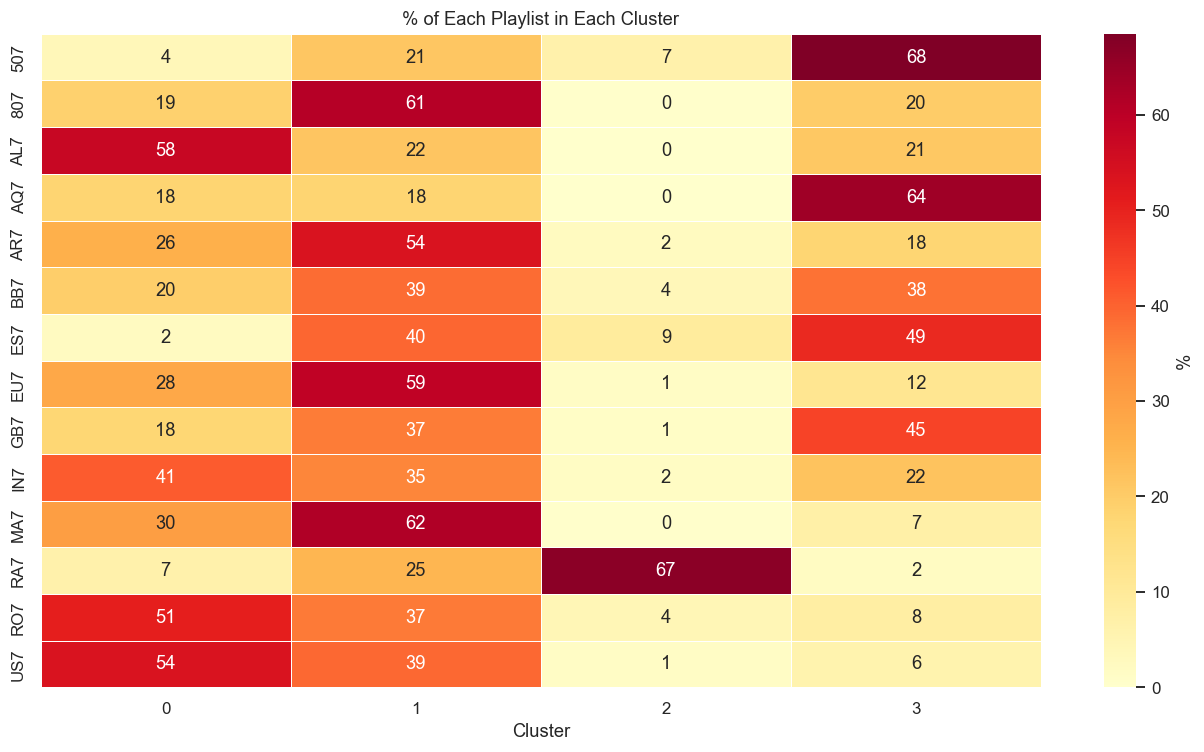

In [25]:
# Heatmap: what % of each playlist lands in each cluster
alignment = (df.groupby(['playlist_name', 'cluster'])
               .size()
               .unstack(fill_value=0))
alignment_pct = alignment.div(alignment.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(alignment_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '%'})
ax.set_title('% of Each Playlist in Each Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Playlists with a dominant cluster (strong personality):

- 507 → 68% in Cluster 3 — still strongly concentrated, character preserved
- RA7 → 67% in Cluster 2 — now correctly isolated, speechiness_log did its job
- AQ7 → 64% in Cluster 3 — shifted from acoustic-dark to whatever cluster 3 now represents
- MA7 → 62% in Cluster 1 — strong concentration
- 807 → 61% in Cluster 1 — high concentration, likely the high-energy dance cluster
- EU7 → 59% in Cluster 1 — same territory as 807
- AR7 → 54% in Cluster 1

Playlists with no dominant cluster (musically diverse):

- BB7 → most spread (20/39/4/38) — still the most eclectic 
- IN7 → fairly even split (41/35/2/22)
- AL7 → 58% in Cluster 0 — actually gained personality with the new model
- RO7, US7 → still splitting across 0 and 1 — diverse as predicted


## 7. Dominant Playlist per Cluster

In [26]:
# For each cluster: which playlist contributes most?
dominant = (df.groupby(['cluster', 'playlist_name'])
              .size()
              .reset_index(name='count')
              .sort_values(['cluster', 'count'], ascending=[True, False])
              .groupby('cluster')
              .first()
              .reset_index()[['cluster', 'playlist_name', 'count']])
dominant.columns = ['cluster', 'dominant_playlist', 'track_count']
print(dominant.to_string(index=False))

 cluster dominant_playlist  track_count
       0               IN7          149
       1               807          225
       2               RA7           70
       3               GB7          140


## 8. Observations

- **Chosen k=4**: silhouette peaks at k=2 (acoustic vs electronic) but is too coarse;
  elbow shows diminishing returns after k=5. k=4 gives interpretable sub-clusters
  while keeping the acoustic/electronic primary split intact.

- **PCA variance explained**: 56.6% (PC1=33.9%, PC2=22.7%). Lower than a purely
  tonal 5-feature model because speechiness_log is largely orthogonal to energy/
  acousticness — it adds a genuinely new dimension that 2D cannot fully capture.
  The scatter plot shows broad structure but cluster separation is cleaner in the
  full 6D space than it appears visually.

- **Cluster → playlist alignment**: mixed. Some playlists map cleanly, most don't.
  The algorithm cuts across playlist boundaries, which means your curation wasn't
  purely audio-driven.

- **Most pure playlists** (strong cluster concentration):
  - 507 → 66% Cluster 0 (Acoustic · Dark)
  - RA7 → 70% Cluster 3 (High Energy · Happy · Danceable)
  - AQ7 → 52% Cluster 0 (Acoustic · Dark)
  - ES7 → 51% Cluster 0 (Acoustic · Dark)

- **Most spread playlists** (no dominant cluster):
  - RO7, US7 → roughly even split across clusters 1/2/3
  - BB7 → spread across all four clusters
  - AL7 → leans cluster 2 (39%) but still distributed

- **Key insight**: KMeans found 4 clusters primarily driven by acousticness (cluster 0
  vs the rest) then subdivided by valence and tempo. Dominant playlist per cluster:
  507 (acoustic), IN7 (fast/high energy), IN7 (dark/high energy), 807 (happy/danceable).
  Playlists like 507, RA7, and AQ7 reflect coherent audio curation — the algorithm
  agrees with your taste. RO7, US7, and BB7 have identity beyond audio features,
  likely era or genre, which motivates adding decade and genre encoding in 03_classifier.

In [27]:
import pickle

with open("../models/kmeans.pkl", "wb") as f:
    pickle.dump(km_final, f)

with open("../models/kmeans_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved kmeans.pkl and kmeans_scaler.pkl")

Saved kmeans.pkl and kmeans_scaler.pkl


In [30]:
pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=FEATURES
).round(3)

,energy,acousticness,valence,tempo,danceability,speechiness_log
0,0.749,0.095,0.448,136.926,0.445,0.049
1,0.714,0.167,0.749,116.507,0.652,0.041
2,0.715,0.216,0.651,119.868,0.681,0.229
3,0.365,0.597,0.384,108.455,0.508,0.037
